## ⚠️ Requires GPU
(would be very slow on CPU)

In [ ]:
!pip install blue_sampler pykeops geomloss

In [ ]:
import torch
import math
from geomloss import SamplesLoss

# -----------------------
# 1. Setup
# -----------------------
device = "cuda"

N = 1024*128
dim = 2

# points init dans [0, 2π]^2
X = torch.rand(N, dim, device=device, requires_grad= True)

optimizer = torch.optim.Adam([X], lr=0.001)

# -----------------------
# 2. Distance toroïdale
# -----------------------
def torus_cost(x, y):
    """
    Cost matrix compatible Sinkhorn sur T².
    Distance périodique smooth via sin.
    """
    diff = (x[:, None, :] - y[None, :, :])# - torch.floor(x[:, None, :] - y[None, :, :])
    return torch.sqrt((diff ** 2).sum(-1))

# -----------------------
# 3. Sinkhorn OT sur tore
# -----------------------
criterion = SamplesLoss(
    loss="sinkhorn",
    blur=0.001
)

# -----------------------
# 4. Optimisation
# -----------------------
for step in range(200):

    optimizer.zero_grad()

    # cible uniforme sur le tore
    Y = torch.rand(N, dim, device=device)

    loss = criterion(X, Y)
    loss.backward()

    optimizer.step()

    # optionnel mais IMPORTANT :
    # projection douce pour rester dans [0, 2π]
    with torch.no_grad():
        X.clamp_(0, 1)

    if step % 20 == 0:
        print(f"step {step} | loss = {loss.item():.4f}")

# -----------------------
# 5. Résultat
# -----------------------
X = X.detach().cpu().numpy()

step 0 | loss = 0.0000
step 20 | loss = 0.0000
step 40 | loss = 0.0000
step 60 | loss = 0.0000
step 80 | loss = 0.0000
step 100 | loss = 0.0000
step 120 | loss = 0.0000
step 140 | loss = 0.0000
step 160 | loss = 0.0000
step 180 | loss = 0.0000


In [ ]:
import blue_sampler as blue
#x = blue.sample(N = 100, D = 2)

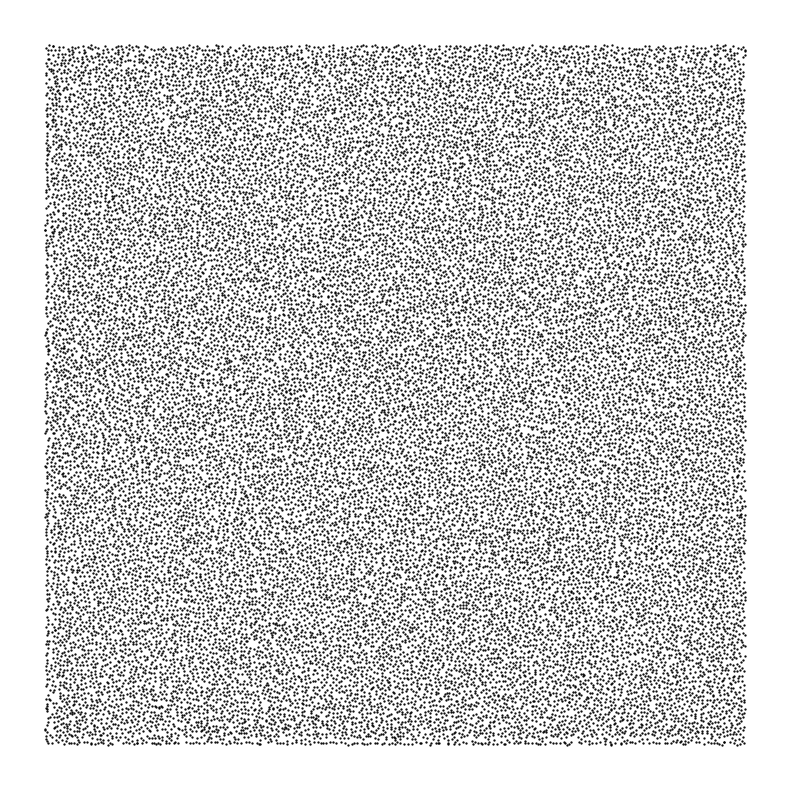

In [ ]:
_ = blue.plot(X)

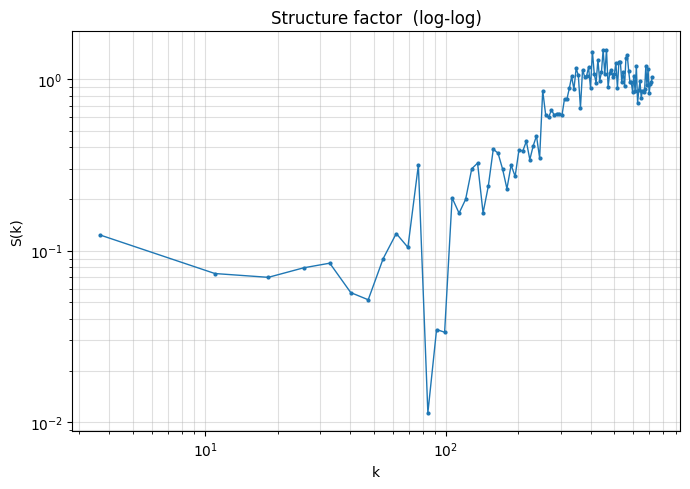

In [ ]:
_ = blue.plot_structure_factor(X)